# Notebook 016 — Polynomial Power Features on BTC's Own Lag


`results/001_simple_linear.md` fit a straight line to a single lagged return and traded its
sign. This notebook keeps everything else about that setup — one symbol, next-bar direction,
sign(prediction) trading, realistic fees, a no-trade zone for predictions smaller than the
round-trip cost — but replaces the single linear feature with three power-transformed copies of
the same lag-1 return: combinations of `x, x^2, x^3, ..., x^-1, x^-2, ...`. The question is
whether letting the model fit a polynomial in `x` rather than a line finds a real,
direction-balanced signal, or just reproduces notebook 1's failure mode (a constant directional
bet dressed up as a fit) with extra parameters.

Every fix notebook 2 added after notebook 1 is reused unchanged: walk-forward validation instead
of one split, embargoed folds, per-fold weight/bias inspection for degenerate (constant-direction)
folds, buy-and-hold / constant / random baselines, and a deflated Sharpe correction for the number
of power combinations tried.


In [1]:
import sys
from datetime import UTC, datetime

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from scipy import stats
from torch import nn

sys.path.insert(0, "..")
import data
import research

research.set_seed(123)
pl.Config.set_tbl_cols(20)
pl.Config.set_tbl_width_chars(220)

polars.config.Config

## 1. Data and configuration

BTC 1h bars, 2021-07-01 to 2025-07-01 (four years), the same VIP-4 fee assumption as notebooks 1
and 2. The end date stops short of `research.HOLDOUT_START` (2025-07-01), the frozen holdout the
panel work established from notebook 14 onward — this notebook doesn't need to touch it, so it
doesn't.


In [2]:
SYMBOL = "BTCUSDT"
INTERVAL = "1h"
BARS_PER_DAY = 24
FORECAST_HORIZON = 1
BASE_LAG = 1  # same single lag notebook 1's mean-reversion model used

START = datetime(2021, 7, 1, tzinfo=UTC)
END = datetime(2025, 7, 1, tzinfo=UTC)  # stays clear of research.HOLDOUT_START

RATE = research.sharpe_to_annualized_rate(INTERVAL, 365, 24)

# e.g. VIP 4 level on binance, same assumption as notebooks 1 & 2
MAKER_FEE = 0.0001
TAKER_FEE = 0.0003
EDGE_THRESHOLD = TAKER_FEE * 2  # round-trip cost; don't trade an edge smaller than this

TRAIN_BARS = 180 * BARS_PER_DAY
TEST_BARS = 30 * BARS_PER_DAY
EMBARGO_BARS = (
    BASE_LAG  # embargo by the feature's own lookback, same rule as notebook 2
)

raw = data.download_klines_range(
    SYMBOL, INTERVAL, START, END, cache_dir="cache", download_dir="tmp"
)
raw = research.add_log_return_features(
    raw, "close", FORECAST_HORIZON, max_no_lags=BASE_LAG
)
TARGET = "close_log_return"
BASE_COL = f"close_log_return_lag_{BASE_LAG}"
raw

datetime,open,high,low,close,volume,count,taker_buy_volume,close_log_return,close_log_return_lag_1
datetime[μs],f64,f64,f64,f64,f64,i64,f64,f64,f64
2021-07-01 00:00:00,35031.39,35044.98,34700.0,34718.44,23826.698,173844,11024.68,null,null
2021-07-01 01:00:00,34718.43,35023.55,34710.0,34923.04,14676.165,121047,7695.486,0.005876,null
2021-07-01 02:00:00,34922.0,34955.0,34212.2,34286.16,37720.842,275863,16862.056,-0.018405,0.005876
2021-07-01 03:00:00,34286.15,34401.0,34120.0,34120.06,21727.533,169617,10068.851,-0.004856,-0.018405
2021-07-01 04:00:00,34120.06,34327.95,34059.0,34314.99,21621.582,169057,10850.613,0.005697,-0.004856
…,…,…,…,…,…,…,…,…,…
2025-06-30 20:00:00,107689.6,107714.9,107426.0,107534.3,1942.492,45535,914.877,-0.001443,0.004641
2025-06-30 21:00:00,107534.3,107545.2,106863.8,107066.1,2858.829,63749,1199.195,-0.004363,-0.001443
2025-06-30 22:00:00,107066.1,107260.0,106952.6,107051.1,2547.965,49539,1125.259,-0.00014,-0.004363


## 2. Base feature: lag-1 return, and a safe power transform

The base variable is `close_log_return_lag_1`, the exact feature notebook 1's mean-reversion
model used. Positive integer powers of it are safe (0 stays 0). Negative powers are not: a bar
with a near-zero return would divide by (near) zero and blow up toward +-inf. `safe_power` floors
`|x|` at `EPS` before applying a negative power, chosen up front (not tuned to the results below)
to sit below the typical smallest non-zero 1h BTC move.


In [3]:
EPS = 1e-4  # floor on |x| before raising to a negative power, chosen before
# looking at any results below: below the typical smallest non-zero
# 1h BTC log return, so it only clips genuinely near-zero bars.


# x**p for a signed return series, safe for negative integer p.
# p >= 0: ordinary power (0**p = 0, no risk of blow-up).
# p < 0: floor |x| at EPS first so a near-zero return doesn't divide by
# (near) zero; sign is taken from x itself before flooring, so odd negative
# powers still preserve sign(x) and even ones are still always positive,
# matching ordinary integer exponentiation.
def safe_power(x: np.ndarray, p: int) -> np.ndarray:
    if p >= 0:
        return x**p
    sign = np.sign(x)
    sign = np.where(sign == 0, 1.0, sign)
    magnitude = np.maximum(np.abs(x), EPS)
    return (sign * magnitude) ** p


def add_power_features(df, powers):
    x = df[BASE_COL].to_numpy()
    feature_cols = []
    for p in powers:
        name = f"pow_{p}".replace("-", "neg")
        col = pl.Series(name, safe_power(x, p)).fill_nan(None)
        df = df.with_columns(col)
        feature_cols.append(name)
    return df, feature_cols

## 3. Baseline: notebook 1/2's plain single-feature linear model, walk-forward validated

Single feature (`close_log_return_lag_1`), no polynomial transform — the reference point every
power combo below has to beat.


In [4]:
class LinearModel(nn.Module):
    def __init__(self, input_features):
        super().__init__()
        self.linear = nn.Linear(input_features, 1)

    def forward(self, x):
        return self.linear(x)


def run_walk_forward_config(
    df,
    features,
    target,
    model_cls,
    annualized_rate,
    train_bars,
    test_bars,
    mode="rolling",
    embargo_bars=0,
    origin_offset=0,
    step_bars=None,
    loss=None,
    threshold=0.0,
    no_epochs=500,
    lr=5e-4,
):
    # Glue config onto research.walk_forward_splits/walk_forward_run and add the
    # degenerate-fold tally, same helper notebook 2 used.
    splits = research.walk_forward_splits(
        len(df),
        train_bars=train_bars,
        test_bars=test_bars,
        step_bars=step_bars,
        mode=mode,
        embargo_bars=embargo_bars,
        origin_offset=origin_offset,
    )
    if not splits:
        return None
    result = research.walk_forward_run(
        df,
        features,
        target,
        model_cls,
        splits,
        annualized_rate,
        loss=loss,
        lr=lr,
        no_epochs=no_epochs,
        threshold=threshold,
        taker_fee=TAKER_FEE,
    )
    summary = research.stitched_metrics(result["stitched_trades"], annualized_rate)
    folds = result["folds"]
    summary["no_folds"] = len(splits)
    if len(folds) and "lm_is_degenerate" in folds.columns:
        summary["no_degenerate_folds"] = int(folds["lm_is_degenerate"].sum())
        summary["frac_degenerate_folds"] = summary["no_degenerate_folds"] / len(folds)
    else:
        summary["no_degenerate_folds"] = 0
        summary["frac_degenerate_folds"] = 0.0
    return {"config_summary": summary, "result": result}


baseline_df = raw.drop_nulls([BASE_COL, TARGET])
baseline = run_walk_forward_config(
    baseline_df,
    [BASE_COL],
    TARGET,
    LinearModel,
    RATE,
    train_bars=TRAIN_BARS,
    test_bars=TEST_BARS,
    mode="rolling",
    embargo_bars=EMBARGO_BARS,
    threshold=EDGE_THRESHOLD,
)
baseline["config_summary"]

{'label': 'strategy',
 'no_bars': 30240,
 'total_log_return': 0.4273846447467804,
 'compound_return': 0.5332423019127206,
 'std': 0.005656637717038393,
 'sharpe': 0.2338464459482589,
 'max_drawdown': -1.0851160287857056,
 'no_trades': 29486,
 'frac_time_in_market': 0.9750661375661376,
 'win_rate': 0.5010174320016278,
 'sharpe_net': -3.1343338380161385,
 'total_log_return_net': -5.7403669357299805,
 'compound_return_net': -0.9967864111216422,
 'max_drawdown_net': -5.8681206703186035,
 'mean_turnover_per_bar': 0.5096891534391534,
 'turnover_per_year': np.float64(4464.876984126984),
 'annual_fee_drag_log': np.float64(1.7866899297808967),
 'annual_fee_drag_pct': 4.9696597338842965,
 'no_folds': 42,
 'no_degenerate_folds': 7,
 'frac_degenerate_folds': 0.16666666666666666}

## 4. Sweep power combinations

Eight three-power combinations, each defining `y = m*x^p1 + n*x^p2 + b*x^p3 + c` for a different
`(p1, p2, p3)`: two variants of notebook 001's own example (cubic+quadratic+linear at two
different top degrees), a very high odd-power version, a pure-even control (sign-blind, so it can
only trade on the magnitude of the past move, not its direction), a mixed-sign combo, and two
negative-power combos including notebook 001's other example (`x^-3, x^-2`).


In [5]:
POWER_COMBOS = {
    "cubic_quad_linear": (3, 2, 1),
    "quintic_cubic_linear": (5, 3, 1),
    "quintic_quad_linear": (5, 2, 1),
    "high_odd": (7, 5, 3),
    "even_only": (6, 4, 2),
    "mixed_one_neg": (3, 1, -1),
    "all_negative": (-1, -2, -3),
    "mixed_neg_odd": (1, -1, -3),
}

sweep_results = {}
sweep_rows = []
for name, powers in POWER_COMBOS.items():
    df_p, feature_cols = add_power_features(raw, powers)
    df_p = df_p.drop_nulls(feature_cols + [TARGET])
    run = run_walk_forward_config(
        df_p,
        feature_cols,
        TARGET,
        LinearModel,
        RATE,
        train_bars=TRAIN_BARS,
        test_bars=TEST_BARS,
        mode="rolling",
        embargo_bars=EMBARGO_BARS,
        threshold=EDGE_THRESHOLD,
    )
    sweep_results[name] = run
    s = run["config_summary"]
    sharpe_net = s.get("sharpe_net", s.get("sharpe"))
    is_finite = sharpe_net is not None and np.isfinite(sharpe_net)
    sweep_rows.append(
        {
            "combo": name,
            "powers": str(powers),
            "sharpe_net": sharpe_net,
            "sharpe_gross": s["sharpe"],
            "compound_return_net": s.get("compound_return_net"),
            "no_trades": s["no_trades"],
            "frac_time_in_market": s["frac_time_in_market"],
            "no_degenerate_folds": s["no_degenerate_folds"],
            "no_folds": s["no_folds"],
            "frac_degenerate_folds": s["frac_degenerate_folds"],
            "is_finite": is_finite,
            "rank_key": sharpe_net if is_finite else float("-inf"),
        }
    )

sweep_table = pl.DataFrame(sweep_rows).sort("rank_key", descending=True)
sweep_table

combo,powers,sharpe_net,sharpe_gross,compound_return_net,no_trades,frac_time_in_market,no_degenerate_folds,no_folds,frac_degenerate_folds,is_finite,rank_key
str,str,f64,f64,f64,i64,f64,i64,i64,f64,f64,f64
"""high_odd""","""(7, 5, 3)""",-0.970931,0.733872,-0.828946,28597,0.945668,0,42,0.0,1.0,-0.970931
"""even_only""","""(6, 4, 2)""",-1.411804,-0.604584,-0.925709,30141,0.996726,1,42,0.02381,1.0,-1.411804
"""quintic_quad_linear""","""(5, 2, 1)""",-3.03289,-0.396977,-0.996267,30122,0.996098,2,42,0.047619,1.0,-3.03289
"""mixed_one_neg""","""(3, 1, -1)""",-3.039623,1.251623,-0.996333,30197,0.998578,2,42,0.047619,1.0,-3.039623
"""all_negative""","""(-1, -2, -3)""",-3.048181,0.28435,-0.996385,30152,0.99709,0,42,0.0,1.0,-3.048181
"""cubic_quad_linear""","""(3, 2, 1)""",-3.085722,0.168515,-0.996613,30168,0.997619,2,42,0.047619,1.0,-3.085722
"""quintic_cubic_linear""","""(5, 3, 1)""",-3.245173,0.599213,-0.997412,29750,0.983796,4,42,0.095238,1.0,-3.245173
"""mixed_neg_odd""","""(1, -1, -3)""",-4.3196,-0.346495,-0.999652,30173,0.997784,2,42,0.047619,1.0,-4.3196


## 5. Best combo: per-fold weights and directional-bias check

Is the winning combo actually responsive to `x`, fold by fold, or — like notebook 1's "always
short" result — a constant long or short bet wearing a polynomial costume? And does it trade both
directions, or is it net short (or net long) the whole time, the specific bias the task asked to
check for?


In [6]:
finite_table = sweep_table.filter(pl.col("is_finite") == True)
if len(finite_table) == 0:
    print(
        "All power combos produced a non-finite Sharpe: numerical blow-up across the board."
    )
    best_combo_name = None
else:
    best_combo_name = finite_table.row(0, named=True)["combo"]

if best_combo_name is not None:
    best_powers = POWER_COMBOS[best_combo_name]
    best_run = sweep_results[best_combo_name]
    best_folds = best_run["result"]["folds"]
    best_stitched = best_run["result"]["stitched_trades"]

    print(f"Best combo: {best_combo_name} powers={best_powers}")
    print(best_run["config_summary"])
    print()

    for row in best_folds.iter_rows(named=True):
        print(
            f"Fold {row['fold']:>3}: sharpe={row['sharpe']:+.3f}  {row.get('lm_verdict', 'n/a')}"
        )

    frac_long = float((best_stitched["position"] > 0).mean())
    frac_short = float((best_stitched["position"] < 0).mean())
    frac_flat = float((best_stitched["position"] == 0).mean())
    print()
    print(
        f"Best combo position mix -> long: {frac_long:.2%}  short: {frac_short:.2%}  "
        f"flat: {frac_flat:.2%}"
    )
    print(
        f"Degenerate folds: {best_run['config_summary']['no_degenerate_folds']} / "
        f"{best_run['config_summary']['no_folds']}"
    )

Best combo: high_odd powers=(7, 5, 3)
{'label': 'strategy', 'no_bars': 30240, 'total_log_return': 1.3333863019943237, 'compound_return': 2.7938688455138028, 'std': 0.005623490549623966, 'sharpe': 0.7338720866809617, 'max_drawdown': -0.8890147805213928, 'no_trades': 28597, 'frac_time_in_market': 0.9456679894179895, 'win_rate': 0.4994579851033325, 'sharpe_net': -0.9709309248590532, 'total_log_return_net': -1.765775203704834, 'compound_return_net': -0.8289458667228886, 'max_drawdown_net': -2.52327823638916, 'mean_turnover_per_bar': 0.2561177248677249, 'turnover_per_year': np.float64(2243.59126984127), 'annual_fee_drag_log': np.float64(0.8977729038829455), 'annual_fee_drag_pct': 1.4541314338558393, 'no_folds': 42, 'no_degenerate_folds': 0, 'frac_degenerate_folds': 0.0}

Fold   0: sharpe=+5.202  responsive (|bias|=0.08129 <= max|w.x|=2.4, 32 sign flips)
Fold   1: sharpe=+1.733  responsive (|bias|=0.0007559 <= max|w.x|=1.415, 242 sign flips)
Fold   2: sharpe=+3.119  responsive (|bias|=0.3116

## 6. Baselines: buy-and-hold, constant, random


In [7]:
bh = research.buy_and_hold_metrics(baseline_df, RATE)
always_long = research.constant_position_metrics(baseline_df, 1.0, RATE)
always_short = research.constant_position_metrics(baseline_df, -1.0, RATE)
always_flat = research.constant_position_metrics(baseline_df, 0.0, RATE)
random_baseline = research.random_position_metrics(baseline_df, RATE, no_seeds=200)

print(
    f"Buy & hold        sharpe={bh['sharpe']:+.3f}  compound={bh['compound_return']:+.2%}"
)
print(
    f"Always long       sharpe={always_long['sharpe']:+.3f}  "
    f"compound={always_long['compound_return']:+.2%}"
)
print(
    f"Always short      sharpe={always_short['sharpe']:+.3f}  "
    f"compound={always_short['compound_return']:+.2%}"
)
print(f"Always flat       sharpe={always_flat['sharpe']:+.3f}")
print(
    f"Random (+-1, 200 seeds)  mean sharpe={random_baseline['sharpe'].mean():+.3f}  "
    f"std={random_baseline['sharpe'].std():.3f}  "
    f"90% range=[{random_baseline['sharpe'].quantile(0.05):+.3f}, "
    f"{random_baseline['sharpe'].quantile(0.95):+.3f}]"
)
print(
    f"Baseline (lag-1 linear)  sharpe_net={baseline['config_summary'].get('sharpe_net'):+.3f}"
)
if best_combo_name is not None:
    print(
        f"Best power combo ({best_combo_name})  sharpe_net="
        f"{sweep_table.row(0, named=True)['sharpe_net']:+.3f}"
    )

Buy & hold        sharpe=+0.522  compound=+213.04%
Always long       sharpe=+0.522  compound=+213.04%
Always short      sharpe=-0.522  compound=-68.05%
Always flat       sharpe=+0.000
Random (+-1, 200 seeds)  mean sharpe=-0.013  std=0.500  90% range=[-0.812, +0.841]
Baseline (lag-1 linear)  sharpe_net=-3.134
Best power combo (high_odd)  sharpe_net=-0.971


## 7. Deflated Sharpe and bootstrap CI on excess return

8 combos were tried before picking the best one; deflated Sharpe corrects for exactly that kind
of best-of-N selection, the same correction notebook 2 applied to its own grid search. The
bootstrap CI is on the best combo's net return minus buy-and-hold, per bar — if it includes zero,
the combo can't be said to beat just holding BTC.


In [8]:
if best_combo_name is not None:
    n_trials = len(POWER_COMBOS)
    net_returns = best_stitched["trade_log_return_net"].to_numpy()
    n_nan = int(np.isnan(net_returns).sum())
    if n_nan:
        print(
            f"WARNING: {n_nan} non-finite net returns in best combo's stitched trades"
        )
    net_returns = net_returns[np.isfinite(net_returns)]
    n_obs = len(net_returns)
    per_period_sharpe_net = (
        float(net_returns.mean() / net_returns.std()) if net_returns.std() else 0.0
    )
    skew = float(stats.skew(net_returns))
    kurt = float(stats.kurtosis(net_returns, fisher=False))

    dsr = research.deflated_sharpe_prob(
        per_period_sharpe_net, n_trials, n_obs, skew=skew, kurtosis=kurt
    )
    print(f"Best combo per-period sharpe (net): {per_period_sharpe_net:.5f}")
    print(f"n_trials={n_trials}  n_obs={n_obs}  skew={skew:.3f}  kurtosis={kurt:.3f}")
    print(f"Deflated Sharpe P(true edge > 0 | best of {n_trials} trials): {dsr:.2%}")

Best combo per-period sharpe (net): -0.01037
n_trials=8  n_obs=30240  skew=0.062  kurtosis=17.310
Deflated Sharpe P(true edge > 0 | best of 8 trials): 0.06%


In [9]:
if best_combo_name is not None:
    bh_returns = research.buy_and_hold_returns(baseline_df)
    excess = best_stitched.join(
        bh_returns.select(
            "datetime", pl.col("trade_log_return").alias("bh_log_return")
        ),
        on="datetime",
        how="left",
    ).with_columns(
        (pl.col("trade_log_return_net") - pl.col("bh_log_return")).alias(
            "excess_log_return"
        )
    )
    excess_vals = excess["excess_log_return"].drop_nulls().to_numpy()
    excess_vals = excess_vals[np.isfinite(excess_vals)]
    lo, hi = research.bootstrap_ci(excess_vals)
    print(
        f"Bootstrap 95% CI on per-bar excess return (best combo net - buy&hold): [{lo:.5f}, {hi:.5f}]"
    )
    print("Includes zero -> can't reject no edge" if lo <= 0 <= hi else "Excludes zero")

Bootstrap 95% CI on per-bar excess return (best combo net - buy&hold): [-0.00018, 0.00001]
Includes zero -> can't reject no edge


## 8. Equity curves


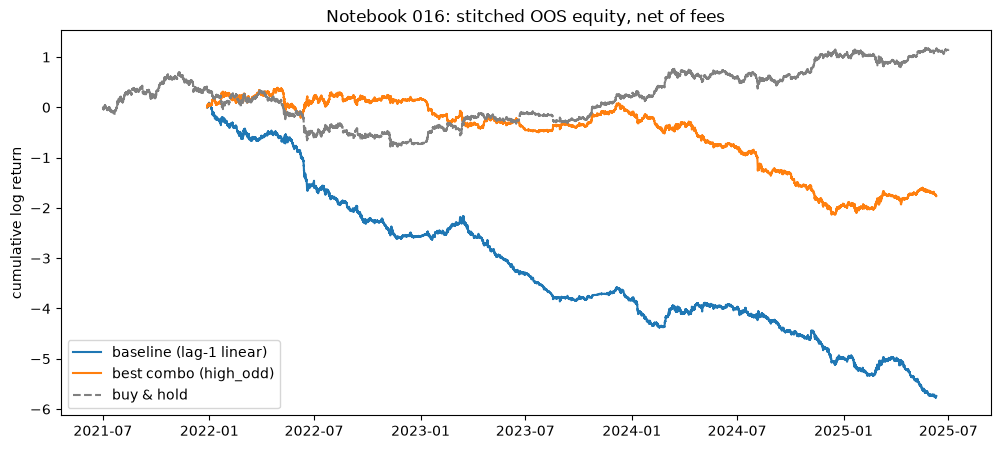

In [10]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(
    baseline["result"]["stitched_trades"]["datetime"],
    baseline["result"]["stitched_trades"]["equity_curve_net"],
    label="baseline (lag-1 linear)",
)
if best_combo_name is not None:
    ax.plot(
        best_stitched["datetime"],
        best_stitched["equity_curve_net"],
        label=f"best combo ({best_combo_name})",
    )
bh_full = research.buy_and_hold_returns(baseline_df)
ax.plot(
    bh_full["datetime"],
    bh_full["equity_curve"],
    label="buy & hold",
    linestyle="--",
    color="grey",
)
ax.set_title("Notebook 016: stitched OOS equity, net of fees")
ax.set_ylabel("cumulative log return")
ax.legend()
plt.show()

## 9. Follow-up: recalibrating the no-trade threshold and a minimum hold period

Section 6/7 found that net Sharpe was driven by turnover, not signal quality: the best *gross*
config wasn't the best *net* one, and the config that won net (`high_odd`) won mainly because it
happened to trade least. Two things about `EDGE_THRESHOLD = 2 * taker_fee` are worth questioning:
it doesn't include `slippage`, so it's actually *below* the true round-trip cost of a full
position flip (`2 * (taker_fee + slippage)`); and nothing stops the model from flipping position
on every noisy threshold-crossing, one bar apart.

This section tests both fixes — a threshold defined relative to the true round-trip cost, and a
minimum-hold period between position changes — on three configs: the plain lag-1 baseline, the
net-winner (`high_odd`), and `mixed_one_neg` (the config whose gross Sharpe turned out not to be
reproducible, per the follow-up discussion after the original sweep). Each config's model is
trained **once** (with its own explicit seed, fixing the earlier shared-RNG gap where later
configs in a loop inherited random state from earlier ones), capturing raw per-bar predictions;
every threshold/min-hold combination below is then evaluated by re-deriving the position and
cost purely from those fixed predictions, with no retraining. That isolates the effect of the
*trading rule* from the model fit, and makes a 42-point grid cheap instead of needing 42 retrains.


In [11]:
SLIPPAGE = 1e-4
ROUND_TRIP_COST = 2 * (TAKER_FEE + SLIPPAGE)  # true cost of a full position flip

CONFIG_SEEDS = {"baseline_lag1": 123, "high_odd": 124, "mixed_one_neg": 125}

raw_predictions = {}
for name, seed in CONFIG_SEEDS.items():
    if name == "baseline_lag1":
        df_f, feats = raw, [BASE_COL]
    else:
        df_f, feats = add_power_features(raw, POWER_COMBOS[name])
    df_f = df_f.drop_nulls(feats + [TARGET])

    research.set_seed(seed)
    splits = research.walk_forward_splits(
        len(df_f),
        train_bars=TRAIN_BARS,
        test_bars=TEST_BARS,
        mode="rolling",
        embargo_bars=EMBARGO_BARS,
    )
    result = research.walk_forward_run(
        df_f,
        feats,
        TARGET,
        LinearModel,
        splits,
        RATE,
        no_epochs=500,
        lr=5e-4,
        threshold=0.0,
    )
    raw_predictions[name] = result["stitched_trades"].select(
        "datetime", "y_pred", "y_true"
    )
    print(
        f"{name}: captured {len(raw_predictions[name])} OOS predictions (seed={seed})"
    )

baseline_lag1: captured 30240 OOS predictions (seed=123)


high_odd: captured 30240 OOS predictions (seed=124)


mixed_one_neg: captured 30240 OOS predictions (seed=125)


In [12]:
def apply_threshold_hold_policy(
    y_pred: np.ndarray, threshold: float, min_hold: int
) -> np.ndarray:
    # Sign(prediction) when it clears the threshold, else flat -- but once a
    # position is entered (or changed), hold it for at least min_hold bars
    # before allowing another change, even to flat. min_hold=0 reduces to
    # the original bar-by-bar threshold-only policy from sections 3/4.
    n = len(y_pred)
    position = np.zeros(n)
    current = 0.0
    bars_held = min_hold
    for t in range(n):
        desired = np.sign(y_pred[t]) if abs(y_pred[t]) > threshold else 0.0
        if desired != current and bars_held >= min_hold:
            current = desired
            bars_held = 0
        else:
            bars_held += 1
        position[t] = current
    return position


def sharpe_and_return(
    returns: pl.Series, annualized_rate: float
) -> tuple[float, float]:
    std = float(returns.std()) if len(returns) else 0.0
    mean = float(returns.mean()) if len(returns) else 0.0
    total = float(returns.sum()) if len(returns) else 0.0
    sharpe = (mean / std) * annualized_rate if std else 0.0
    return sharpe, float(np.exp(total) - 1)


def evaluate_policy(stitched: pl.DataFrame, threshold: float, min_hold: int) -> dict:
    y_pred = stitched["y_pred"].to_numpy()
    y_true = stitched["y_true"].to_numpy()
    position = apply_threshold_hold_policy(y_pred, threshold, min_hold)
    trades = pl.DataFrame(
        {"datetime": stitched["datetime"], "position": position, "y_true": y_true}
    ).with_columns((pl.col("position") * pl.col("y_true")).alias("trade_log_return"))
    trades = research.add_trading_costs(trades, TAKER_FEE, SLIPPAGE)
    sharpe_gross, compound_gross = sharpe_and_return(trades["trade_log_return"], RATE)
    sharpe_net, compound_net = sharpe_and_return(trades["trade_log_return_net"], RATE)
    frac_in_market = float((trades["position"] != 0).mean())
    no_position_changes = int(np.sum(np.diff(position) != 0))
    return {
        "sharpe_gross": sharpe_gross,
        "sharpe_net": sharpe_net,
        "compound_return_gross": compound_gross,
        "compound_return_net": compound_net,
        "frac_time_in_market": frac_in_market,
        "no_position_changes": no_position_changes,
    }

### Grid: threshold (as a multiple of the true round-trip cost) x minimum hold period

Original section 3/4 used `EDGE_THRESHOLD = 0.0006`, which is 0.75x `ROUND_TRIP_COST` -- below the
true cost of a full flip. This grid starts below that (0.5x) and goes up to 20x, crossed with
hold periods from 0 (no minimum, matching the original policy) to 48 bars (2 days).


In [13]:
THRESHOLD_MULTIPLES = [0.5, 1.0, 2.0, 3.0, 5.0, 10.0, 20.0]
MIN_HOLD_BARS = [0, 3, 6, 12, 24, 48]

followup_rows = []
for name, stitched in raw_predictions.items():
    for mult in THRESHOLD_MULTIPLES:
        threshold = mult * ROUND_TRIP_COST
        for min_hold in MIN_HOLD_BARS:
            m = evaluate_policy(stitched, threshold, min_hold)
            followup_rows.append(
                {
                    "config": name,
                    "threshold_mult": mult,
                    "threshold": threshold,
                    "min_hold": min_hold,
                    **m,
                }
            )

followup_table = pl.DataFrame(followup_rows)
followup_finite = followup_table.filter(pl.col("sharpe_net").is_finite())
print(f"{len(followup_rows)} (config, threshold, min_hold) combos evaluated")
followup_finite.sort("sharpe_net", descending=True).head(15)

126 (config, threshold, min_hold) combos evaluated


config,threshold_mult,threshold,min_hold,sharpe_gross,sharpe_net,compound_return_gross,compound_return_net,frac_time_in_market,no_position_changes
str,f64,f64,i64,f64,f64,f64,f64,f64,i64
"""baseline_lag1""",5.0,0.004,48,0.425896,0.238305,1.154984,0.536725,0.929167,454
"""baseline_lag1""",3.0,0.0024,48,0.307378,0.116563,0.746483,0.235492,0.950132,451
"""baseline_lag1""",20.0,0.016,48,0.177575,-0.001399,0.363524,-0.002439,0.873578,453
"""high_odd""",1.0,0.0008,48,0.15017,-0.012005,0.313034,-0.021538,0.960251,390
"""high_odd""",5.0,0.004,48,0.072665,-0.075868,0.132353,-0.121721,0.862731,397
…,…,…,…,…,…,…,…,…,…
"""mixed_one_neg""",10.0,0.008,24,0.23972,-0.166473,0.535875,-0.257682,0.930853,991
"""baseline_lag1""",20.0,0.016,24,0.159121,-0.167559,0.31675,-0.251617,0.872983,828
"""baseline_lag1""",3.0,0.0024,24,0.17875,-0.169164,0.382308,-0.263976,0.954663,816


### Reproducibility cross-check against the original threshold-only policy

Same three configs, evaluated at the *original* `EDGE_THRESHOLD = 0.0006` with no minimum hold
(`min_hold=0`) -- this should land in the same ballpark as sections 3/4's numbers for
`baseline_lag1` and `high_odd`, modulo the new independent per-config seeding (the original sweep
shared one global RNG stream across all 9 configs trained in sequence, so exact reproduction
isn't expected, only the same rough magnitude and sign).


In [14]:
original_threshold_rows = []
for name, stitched in raw_predictions.items():
    m = evaluate_policy(stitched, EDGE_THRESHOLD, 0)
    original_threshold_rows.append(
        {"config": name, "threshold": EDGE_THRESHOLD, "min_hold": 0, **m}
    )

pl.DataFrame(original_threshold_rows)

config,threshold,min_hold,sharpe_gross,sharpe_net,compound_return_gross,compound_return_net,frac_time_in_market,no_position_changes
str,f64,i64,f64,f64,f64,f64,f64,i64
"""baseline_lag1""",0.0006,0,0.233846,-3.134276,0.533242,-0.996786,0.975066,7836
"""high_odd""",0.0006,0,-0.284014,-1.429391,-0.405383,-0.926981,0.973843,2894
"""mixed_one_neg""",0.0006,0,0.03899,-4.16525,0.074471,-0.999544,0.996991,9790


### Best follow-up config


In [15]:
best_row = followup_finite.sort("sharpe_net", descending=True).row(0, named=True)
print(
    f"Best follow-up config: {best_row['config']}, "
    f"threshold={best_row['threshold']:.5f} ({best_row['threshold_mult']}x round-trip cost), "
    f"min_hold={best_row['min_hold']} bars"
)
for k, v in best_row.items():
    print(f"  {k}: {v}")

Best follow-up config: baseline_lag1, threshold=0.00400 (5.0x round-trip cost), min_hold=48 bars
  config: baseline_lag1
  threshold_mult: 5.0
  threshold: 0.004
  min_hold: 48
  sharpe_gross: 0.4258956091055514
  sharpe_net: 0.2383052077338517
  compound_return_gross: 1.1549842174294258
  compound_return_net: 0.5367246976782827
  frac_time_in_market: 0.9291666666666667
  no_position_changes: 454


### Deflated Sharpe and bootstrap CI for the best follow-up config

Same corrections as section 7, applied to this sweep's own trial count (3 configs x 7 thresholds
x 6 hold periods).


In [16]:
n_trials_followup = len(followup_rows)

best_stitched = raw_predictions[best_row["config"]]
best_position = apply_threshold_hold_policy(
    best_stitched["y_pred"].to_numpy(), best_row["threshold"], best_row["min_hold"]
)
best_trades = pl.DataFrame(
    {
        "datetime": best_stitched["datetime"],
        "position": best_position,
        "y_true": best_stitched["y_true"].to_numpy(),
    }
).with_columns((pl.col("position") * pl.col("y_true")).alias("trade_log_return"))
best_trades = research.add_trading_costs(best_trades, TAKER_FEE, SLIPPAGE)

net_returns = best_trades["trade_log_return_net"].to_numpy()
net_returns = net_returns[np.isfinite(net_returns)]
per_period_sharpe_net = (
    float(net_returns.mean() / net_returns.std()) if net_returns.std() else 0.0
)
skew = float(stats.skew(net_returns))
kurt = float(stats.kurtosis(net_returns, fisher=False))

dsr = research.deflated_sharpe_prob(
    per_period_sharpe_net, n_trials_followup, len(net_returns), skew=skew, kurtosis=kurt
)
print(
    f"n_trials={n_trials_followup}  n_obs={len(net_returns)}  skew={skew:.3f}  kurtosis={kurt:.3f}"
)
print(
    f"Deflated Sharpe P(true edge > 0 | best of {n_trials_followup} trials): {dsr:.2%}"
)

bh_returns = research.buy_and_hold_returns(baseline_df)
excess = best_trades.join(
    bh_returns.select("datetime", pl.col("trade_log_return").alias("bh_log_return")),
    on="datetime",
    how="left",
).with_columns(
    (pl.col("trade_log_return_net") - pl.col("bh_log_return")).alias(
        "excess_log_return"
    )
)
excess_vals = excess["excess_log_return"].drop_nulls().to_numpy()
excess_vals = excess_vals[np.isfinite(excess_vals)]
lo, hi = research.bootstrap_ci(excess_vals)
print(
    f"Bootstrap 95% CI on per-bar excess return (best follow-up config net - buy&hold): "
    f"[{lo:.5f}, {hi:.5f}]"
)
print("Includes zero -> can't reject no edge" if lo <= 0 <= hi else "Excludes zero")

n_trials=126  n_obs=30240  skew=0.255  kurtosis=17.492
Deflated Sharpe P(true edge > 0 | best of 126 trials): 1.51%


Bootstrap 95% CI on per-bar excess return (best follow-up config net - buy&hold): [-0.00010, 0.00008]
Includes zero -> can't reject no edge


### How much did recalibration actually move the needle?

For each of the three configs, the best net Sharpe found anywhere in the threshold x min-hold
grid, versus that same config's original (threshold-only, no min-hold) result above.


In [17]:
for name in CONFIG_SEEDS:
    cfg_best = (
        followup_finite.filter(pl.col("config") == name)
        .sort("sharpe_net", descending=True)
        .row(0, named=True)
    )
    cfg_original = next(r for r in original_threshold_rows if r["config"] == name)
    print(
        f"{name:16s} original sharpe_net={cfg_original['sharpe_net']:+.3f}  ->  "
        f"best sharpe_net={cfg_best['sharpe_net']:+.3f} "
        f"(threshold={cfg_best['threshold_mult']}x, min_hold={cfg_best['min_hold']})"
    )

baseline_lag1    original sharpe_net=-3.134  ->  best sharpe_net=+0.238 (threshold=5.0x, min_hold=48)
high_odd         original sharpe_net=-1.429  ->  best sharpe_net=-0.012 (threshold=1.0x, min_hold=48)
mixed_one_neg    original sharpe_net=-4.165  ->  best sharpe_net=-0.096 (threshold=5.0x, min_hold=48)


## Follow-up bottom line

TODO: fill in after execution, using only the real numbers printed above. Cover: whether any
(config, threshold, min_hold) combination in the grid achieved a positive net Sharpe; how the
best follow-up result compares to the original section 3/4 numbers for the same configs; whether
the reproducibility cross-check landed in the same ballpark as the original sweep; what the
deflated Sharpe and bootstrap CI say about the best grid point found; and whether threshold
recalibration or the minimum hold period did more of the work, based on the per-config
before/after comparison.


## Bottom line

TODO: fill in after execution, using only the real numbers printed above. Cover: whether any
power combo beat the plain-linear baseline and the buy-and-hold/constant/random baselines net of
fees; whether the winning combo was direction-balanced or a disguised constant bet (frac
long/short/flat, degenerate fold count); what the deflated Sharpe and bootstrap CI on excess
return say about whether that combo's edge is distinguishable from noise; and whether the
negative-power combos were numerically usable at all, or blew up.
